# Complete descriptive analysis — by hypothesis

OpenMATB transparency study (revised, *wording-only* design). This notebook is the
**single entry point** for the study's descriptive statistics: it loads every
session, builds the tidy per-(participant, form, block) metrics table, and walks
each hypothesis in turn, reporting form-wise means / medians / spreads and the
matching plots.

> **Scope.** *Descriptive only* — group means, dispersion, and distribution plots
> across the three explanation forms (F1 / F2 / F3). Inferential modelling
> (mixed-effects, planned contrasts, the H1×H2 crossover test, workload mediation)
> is deliberately deferred to a later notebook; the tidy table written here is its
> input.

## The manipulation in one line
Information **content** is held constant across F1/F2/F3; only the **linguistic
form** of the aid's explanation changes. F1 = verbose, F2 = contrastive,
F3 = contrastive + actionability cue.

## Hypotheses (and predicted direction across forms)

| H | Construct | Metric(s) | Predicted | Section |
|---|-----------|-----------|-----------|---------|
| **H1** | Subjective transparency (the *feeling*) | `subj_transparency` | **F1 highest** | [§2](#h1) |
| *mech.* | Workload (overwhelm check) | `workload` | **F1 highest** | [§3](#mech) |
| **H2** | Mental-model accuracy (explicability) | `mm_explicability` & parts | **F2/F3 best** | [§4](#h2) |
| — | H1×H2 crossover (descriptive preview) | z(transparency) vs z(explicability) | **opposite** | [§5](#crossover) |
| **H3a** | Miss detection | `detection_rate`, `mean_detect_rt` | **F2/F3 better/faster** | [§6](#h3) |
| **H3b** | Overwrites of correct aid actions | `overwrite_rate` | **F1 highest** | [§6](#h3) |
| **H4** | Non-aided task performance | resman + comms | **F2/F3 better** | [§7](#h4) |
| — | Preference debrief (triangulation) | `PREF_*` | — | [§8](#pref) |

The **H1↔H2 opposition** (F1 feels most transparent yet F2/F3 give the more
accurate mental model) is the explainability ≠ explicability crossover the study
targets.


## 0. Setup

In [ ]:
import sys
from pathlib import Path

# Make the matb_analysis package importable when running from notebooks/.
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.discovery import find_study_sessions
from matb_analysis.validation import validate_sessions
from matb_analysis.aggregate import build_metrics_table, build_debrief_table

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)

FORM_ORDER = ["F1", "F2", "F3"]
FORM_PALETTE = dict(zip(FORM_ORDER, sns.color_palette("Set2", 3)))

OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Analyse the full simulated cohort (N=20, known ground truth). Point this at
# `session_logs` (the default) once real participants are collected, or leave it
# to fold the real pilot in alongside the simulated set.
DATA_DIR = Path.cwd().parent / "session_logs" / "simulated"


### Reusable descriptive helpers
`describe_by_form` returns a mean / median / SD / n table for any metric columns;
`box_by_form` draws one box-+-strip panel per column. Every section below is built
from these two, so the reporting style is identical throughout.

In [2]:
def describe_by_form(df, cols, order=FORM_ORDER):
    """Form-wise mean / median / SD / n for the given metric columns (tidy long)."""
    g = df.groupby("form")
    out = []
    for c in cols:
        s = g[c]
        d = pd.DataFrame({"mean": s.mean(), "median": s.median(),
                          "sd": s.std(), "n": s.count()}).reindex(order)
        d.insert(0, "metric", c)
        out.append(d.reset_index())
    return (pd.concat(out, ignore_index=True)
              .set_index(["metric", "form"]).round(3))


def box_by_form(df, cols, titles=None, order=FORM_ORDER, ncols=2, save=None):
    """One box+strip panel per column, coloured by form."""
    titles = titles or cols
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.0 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col, title in zip(axes, cols, titles):
        sns.boxplot(data=df, x="form", y=col, order=order, hue="form",
                    palette=FORM_PALETTE, legend=False, width=0.6, ax=ax)
        sns.stripplot(data=df, x="form", y=col, order=order, color="0.2",
                      size=3, alpha=0.6, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.tight_layout()
    if save:
        fig.savefig(OUT / save, dpi=150, bbox_inches="tight")
    plt.show()


## 1. Load sessions, validate, build the metrics table

In [3]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} session(s).")
if not sessions:
    raise SystemExit("No sessions found. Generate the cohort with "
                     "`uv run python -m matb_analysis.simulate --n 20`, "
                     "or point DATA_DIR at session_logs/.")

table = build_metrics_table(sessions)
table.to_csv(OUT / "metrics_by_block.csv", index=False)
print(f"Metrics table: {table.shape[0]} rows x {table.shape[1]} cols "
      f"({table['participant'].nunique()} participants).")
table.head()

Reading logs from: c:\Projects\HumanCenteredAI\analysis\session_logs
Discovered 21 session(s).
Metrics table: 63 rows x 42 cols (20 participants).


,participant,form,block,session_file,rmsd_a,rmsd_b,rmsd_mean,mad_a,mad_b,pct_in_tolerance_a,pct_in_tolerance_b,pct_in_tolerance_mean,n_excursions,mean_excursion_sec,n_events,n_signal,n_hit,n_miss,n_fa,n_bad_radio,n_bad_freq,n_bad_radio_freq,accuracy,miss_rate,fa_count,mean_rt_hit,mean_abs_freq_dev,n_aid_miss_events,n_detected,detection_rate,mean_detect_rt,n_aid_handled_events,n_overwrite,overwrite_rate,n_false_alarms,subj_transparency,workload,mm_misses_error,mm_closecalls_error,mm_reliability_error,mm_rec_accuracy,mm_explicability
0,P03,F2,A,26_260602_190745.csv,102.142254,311.637610,206.889932,86.760000,251.293333,100.000000,56.000000,78.000000,2,31.0,8,7,5,2,1,0,0,0,0.714286,0.285714,1,11376.0,0.000000,2,2,1.0,2900.0,7,0,0.000000,0,3.976133,6.013279,0.006346,2.000000,18.740915,1.0,0.868106
1,P03,F1,B,26_260602_190745.csv,69.862495,166.901010,118.381752,53.788079,109.615894,100.000000,86.754967,93.377483,2,55.0,7,6,5,1,1,0,0,0,0.833333,0.166667,1,9184.0,0.000000,2,0,0.0,NaN,7,0,0.000000,0,6.319187,7.000000,2.000000,2.000000,22.222222,1.0,0.785714
2,P03,F3,C,26_260602_190745.csv,153.267848,96.712929,124.990389,116.529801,78.145695,89.403974,100.000000,94.701987,1,32.0,7,7,5,1,0,0,1,0,0.714286,0.142857,0,9040.0,0.016667,2,2,1.0,3000.0,7,0,0.000000,0,4.000000,4.945779,0.006346,0.767916,2.088351,1.0,0.965635
3,P01,F1,A,sim_P01_260601_190045.csv,357.064744,386.295563,371.680153,287.542000,320.372667,81.333333,83.333333,82.333333,2,31.0,8,7,3,2,1,0,2,0,0.428571,0.285714,1,5439.0,0.360000,2,1,0.5,2728.0,7,2,0.285714,0,5.825958,4.350096,1.204987,1.142611,22.222222,0.5,0.719729
4,P01,F2,B,sim_P01_260601_190045.csv,224.712486,235.619488,230.165987,182.952318,190.709272,97.350993,96.688742,97.019868,2,55.0,7,6,5,0,1,0,1,0,0.833333,0.000000,1,4273.4,0.050000,2,2,1.0,2664.5,7,0,0.000000,0,4.759065,3.071950,1.242748,0.216014,7.856924,1.0,0.922647


### 1a. Validation — realised structure vs. study design
Every session is cross-checked: briefing form vs. panel form, panel block vs. the
gauges that actually failed, and the realised (form, block) order vs. the
participant's Latin-square row. Any `ok = False` row must be resolved before the
numbers below can be trusted.

In [4]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with issues.")
if n_bad:
    display(report[~report["ok"]][["session_file", "participant", "issues"]])
report.head()

21 session(s) validated; 0 with issues.


,session_file,participant,kind,ok,n_blocks,realized,expected,issues
0,26_260602_190745.csv,P03,full,True,3,"[(F2, A), (F1, B), (F3, C)]","[(F2, A), (F1, B), (F3, C)]",
1,sim_P01_260601_190045.csv,P01,full,True,3,"[(F1, A), (F2, B), (F3, C)]","[(F1, A), (F2, B), (F3, C)]",
2,sim_P02_260602_190145.csv,P02,full,True,3,"[(F1, A), (F3, B), (F2, C)]","[(F1, A), (F3, B), (F2, C)]",
3,sim_P03_260603_190245.csv,P03,full,True,3,"[(F2, A), (F1, B), (F3, C)]","[(F2, A), (F1, B), (F3, C)]",
4,sim_P04_260604_190345.csv,P04,full,True,3,"[(F2, A), (F3, B), (F1, C)]","[(F2, A), (F3, B), (F1, C)]",


### 1b. Cohort & counterbalancing overview
Each form should appear once per participant, and the form×block crosstab should be
balanced by the Latin square (every form meets every gauge set roughly equally).

In [5]:
n_part = table["participant"].nunique()
print(f"Participants: {n_part}")
print(f"Blocks per form:\n{table['form'].value_counts().reindex(FORM_ORDER).to_string()}")
print("\nform x block (counterbalancing):")
display(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER))

# Sanity: exactly one block per (participant, form).
dup = table.groupby(["participant", "form"]).size()
print(f"\n(participant, form) cells with !=1 block: {(dup != 1).sum()}")

Participants: 20
Blocks per form:
form
F1    21
F2    21
F3    21

form x block (counterbalancing):


block,A,B,C
form,,,
F1,6,7,8
F2,9,6,6
F3,6,8,7



(participant, form) cells with !=1 block: 3


<a id="h1"></a>
## 2. H1 — Subjective transparency  *(predict F1 highest)*

`subj_transparency` is the mean of three 1–7 agreement items (one reverse-keyed):
"the system told me what it was doing", "I could keep track", "the amount of
information felt about right". Higher = the explanation *feels* more transparent.
H1 predicts the verbose form **F1** feels most transparent even though content is
identical.

mean  median     sd   n
metric            form                          
subj_transparency F1    5.546   5.782  0.756  21
                  F2    4.417   4.203  0.606  21
                  F3    4.457   4.426  0.664  21

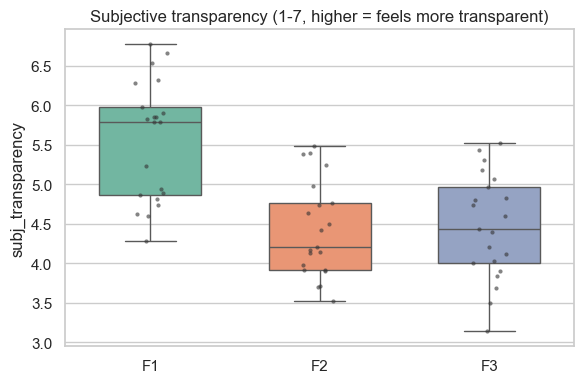

In [6]:
display(describe_by_form(table, ["subj_transparency"]))
box_by_form(table, ["subj_transparency"],
            ["Subjective transparency (1-7, higher = feels more transparent)"],
            ncols=1, save="h1_transparency_by_form.png")

<a id="mech"></a>
## 3. Mechanism check — Workload  *(predict F1 highest)*

Single mental-effort item (1–7). Tests whether any F1 transparency advantage is
confounded by overload — the mediating step behind H2/H4. H1 and this should move
**together** (verbose → feels informed *and* feels demanding).

mean  median     sd   n
metric   form                          
workload F1    5.483   5.431  0.853  21
         F2    4.327   4.383  0.997  21
         F3    4.509   4.308  0.890  21

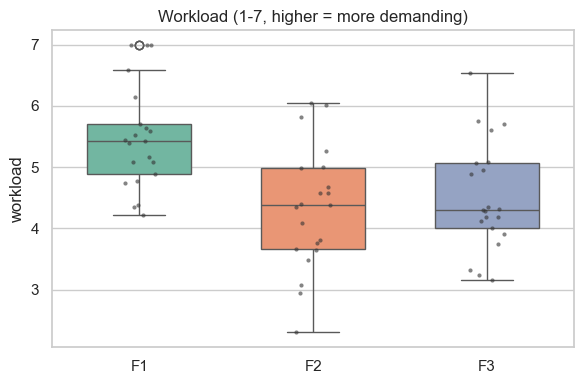

In [7]:
display(describe_by_form(table, ["workload"]))
box_by_form(table, ["workload"],
            ["Workload (1-7, higher = more demanding)"],
            ncols=1, save="workload_by_form.png")

<a id="h2"></a>
## 4. H2 — Mental-model accuracy / explicability  *(predict F2/F3 best)*

The five-slider mental-model probe scored against each block's ground truth:

- `mm_explicability` — composite [0–1] accuracy (higher = better-calibrated model).
- `mm_misses_error`, `mm_closecalls_error` — abs. deviation of the count sliders
  from truth (2 each); **lower = better**.
- `mm_reliability_error` — abs. deviation from ~78 %; **lower = better**.
- `mm_rec_accuracy` — proportion of the two recognition items answered on the
  correct side; **higher = better**.

H2 predicts the contrastive forms **F2/F3** yield the more accurate model — the
*opposite* direction to H1.

mean  median      sd   n
metric               form                            
mm_explicability     F1     0.730   0.728   0.093  21
                     F2     0.897   0.911   0.058  21
                     F3     0.889   0.913   0.055  21
mm_rec_accuracy      F1     0.619   0.500   0.312  21
                     F2     0.929   1.000   0.179  21
                     F3     0.881   1.000   0.218  21
mm_misses_error      F1     1.691   2.000   0.436  21
                     F2     0.923   0.693   0.674  21
                     F3     0.538   0.448   0.443  21
mm_closecalls_error  F1     1.664   2.000   1.147  21
                     F2     0.840   0.732   0.600  21
                     F3     0.959   0.881   0.526  21
mm_reliability_error F1    17.037  17.139  10.811  21
                     F2     7.029   5.986   5.939  21
                     F3     8.711   7.353   6.942  21

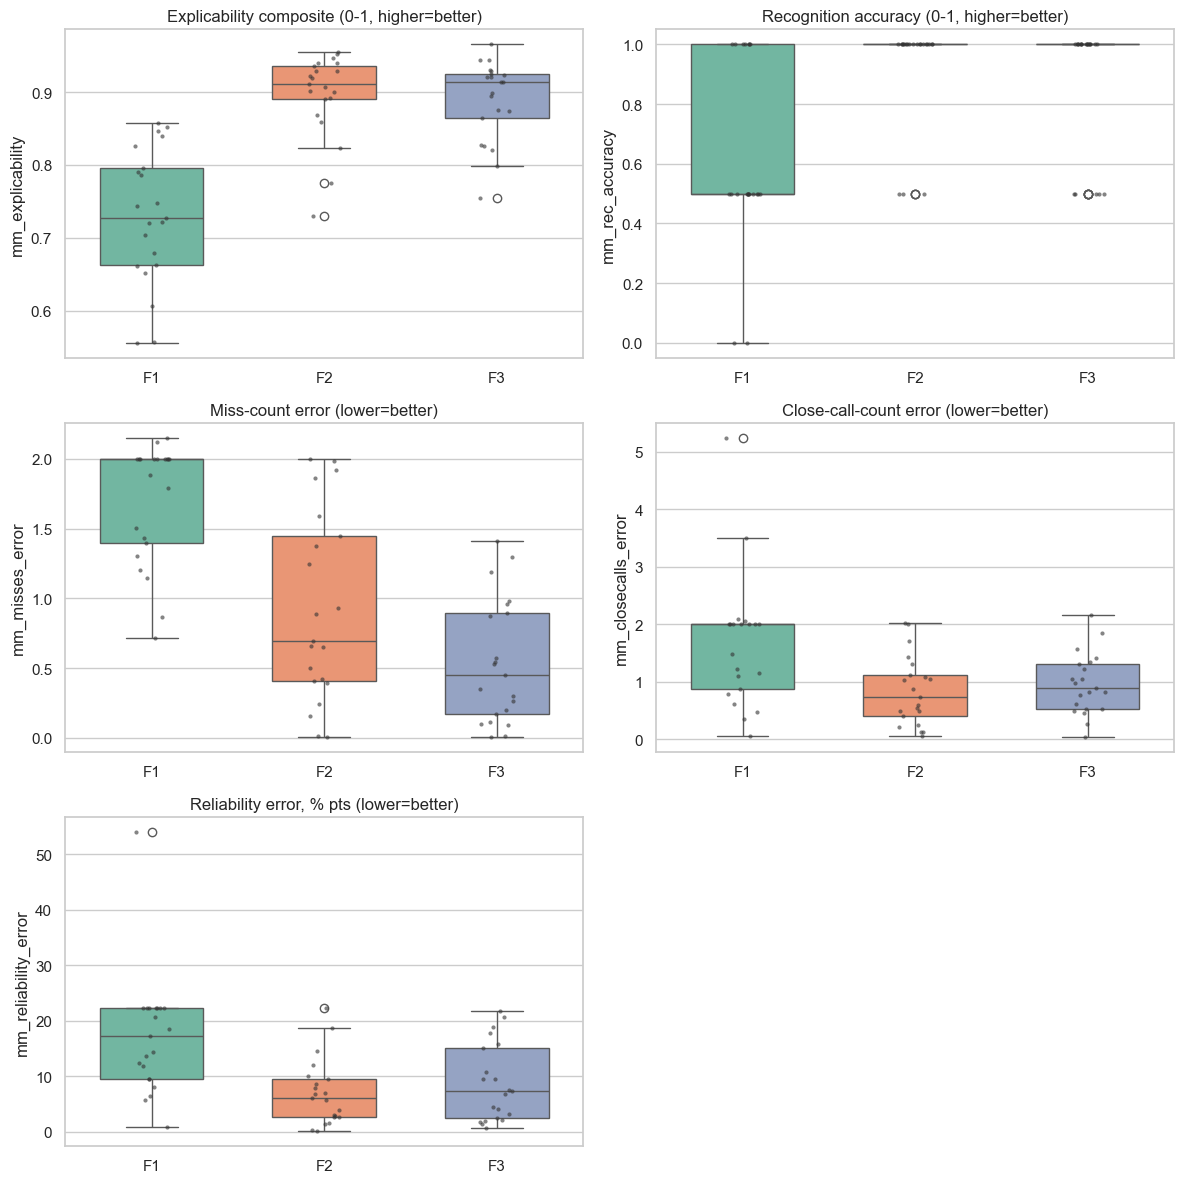

In [8]:
mm_cols = ["mm_explicability", "mm_rec_accuracy", "mm_misses_error",
           "mm_closecalls_error", "mm_reliability_error"]
display(describe_by_form(table, mm_cols))
box_by_form(table, mm_cols,
            ["Explicability composite (0-1, higher=better)",
             "Recognition accuracy (0-1, higher=better)",
             "Miss-count error (lower=better)",
             "Close-call-count error (lower=better)",
             "Reliability error, % pts (lower=better)"],
            ncols=2, save="h2_mentalmodel_by_form.png")

<a id="crossover"></a>
## 5. The H1 × H2 crossover — descriptive preview

The study's core claim is a *dissociation*: the form that feels most transparent
(H1) is **not** the form that builds the most accurate mental model (H2). Plotting
both constructs z-scored to a common scale makes the opposing slopes visible.
*(Descriptive only — the formal form×measure-type interaction test comes later.)*

,z_transparency,z_explicability
form,,
F1,0.869,-1.041
F2,-0.458,0.558
F3,-0.411,0.483


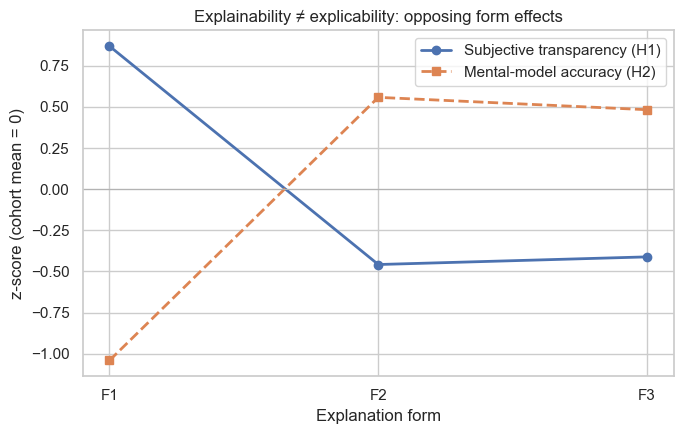

In [9]:
z = table.copy()
z["z_transparency"] = (z["subj_transparency"] - z["subj_transparency"].mean()) / z["subj_transparency"].std()
z["z_explicability"] = (z["mm_explicability"] - z["mm_explicability"].mean()) / z["mm_explicability"].std()

cross = (z.groupby("form")[["z_transparency", "z_explicability"]]
           .mean().reindex(FORM_ORDER))
display(cross.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cross.index, cross["z_transparency"], "o-", lw=2, label="Subjective transparency (H1)")
ax.plot(cross.index, cross["z_explicability"], "s--", lw=2, label="Mental-model accuracy (H2)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_ylabel("z-score (cohort mean = 0)")
ax.set_xlabel("Explanation form")
ax.set_title("Explainability ≠ explicability: opposing form effects")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h1xh2_crossover.png", dpi=150)
plt.show()

<a id="h3"></a>
## 6. H3 — System monitoring  *(H3a: F2/F3 detect more/faster; H3b: F1 overwrites more)*

From the aided sysmon task, split by the aid's `automaticsolver` state at each event:

- **H3a (aid-skipped misses).** `detection_rate` = fraction of aid misses the
  operator caught (higher = better); `mean_detect_rt` = RT on caught misses, ms
  (lower = better).
- **H3b (aid-handled events).** `overwrite_rate` = fraction of correct aid actions
  the operator pre-emptively overwrote (lower = better; H3 predicts F1 highest).
- `n_false_alarms` reported alongside.

> Few misses per block (2) → these estimates are fragile; treat as exploratory.

mean    median       sd   n
metric         form                                 
detection_rate F1       0.476     0.500    0.370  21
               F2       0.833     1.000    0.289  21
               F3       0.905     1.000    0.256  21
mean_detect_rt F1    3733.867  3639.000  789.794  15
               F2    2824.475  2690.500  911.476  20
               F3    2284.350  2294.750  485.787  20
overwrite_rate F1       0.088     0.143    0.084  21
               F2       0.034     0.000    0.062  21
               F3       0.027     0.000    0.057  21
n_false_alarms F1       0.000     0.000    0.000  21
               F2       0.000     0.000    0.000  21
               F3       0.000     0.000    0.000  21

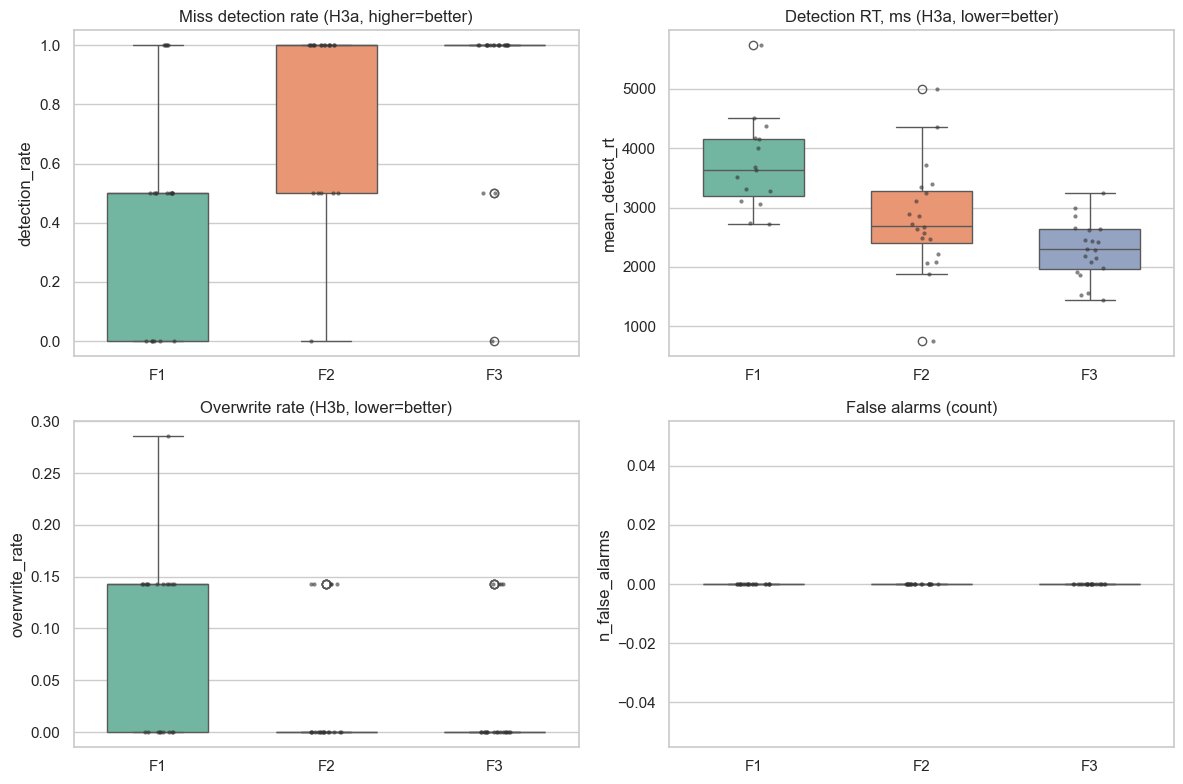

In [10]:
h3_cols = ["detection_rate", "mean_detect_rt", "overwrite_rate", "n_false_alarms"]
display(describe_by_form(table, h3_cols))
box_by_form(table, h3_cols,
            ["Miss detection rate (H3a, higher=better)",
             "Detection RT, ms (H3a, lower=better)",
             "Overwrite rate (H3b, lower=better)",
             "False alarms (count)"],
            ncols=2, save="h3_sysmon_by_form.png")

<a id="h4"></a>
## 7. H4 — Non-aided task performance  *(predict F2/F3 better)*

If the contrastive forms are quicker to read, the saved attention should show up as
better performance on the three **unaided** tasks. Headline measures:

- **Resource management** — `rmsd_mean` (tank deviation from target, lower=better),
  `pct_in_tolerance_mean` (higher=better).
- **Communications** — `accuracy` (hits/signal, higher=better), `mean_rt_hit`
  (ms, lower=better).

mean    median        sd   n
metric                form                                  
rmsd_mean             F1     413.741   410.126    90.578  21
                      F2     295.533   305.213    57.640  21
                      F3     285.327   284.946    65.701  21
pct_in_tolerance_mean F1      77.603    78.667     7.379  21
                      F2      89.446    89.073     6.321  21
                      F3      90.728    92.715     5.711  21
accuracy              F1       0.578     0.571     0.261  21
                      F2       0.900     0.857     0.110  21
                      F3       0.781     0.857     0.219  21
mean_rt_hit           F1    8396.221  8477.667  2104.929  21
                      F2    6881.411  6548.167  1967.105  21
                      F3    6766.894  6805.667  2235.581  21

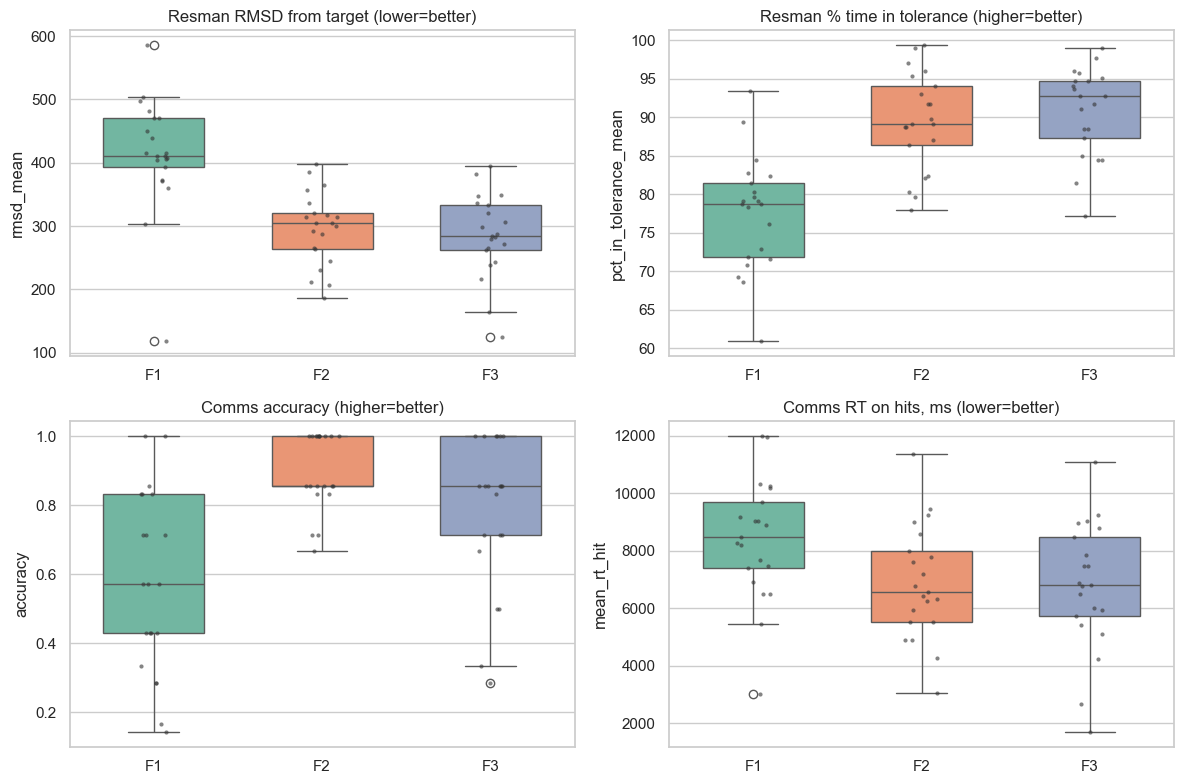

In [11]:
h4_cols = ["rmsd_mean", "pct_in_tolerance_mean", "accuracy", "mean_rt_hit"]
display(describe_by_form(table, h4_cols))
box_by_form(table, h4_cols,
            ["Resman RMSD from target (lower=better)",
             "Resman % time in tolerance (higher=better)",
             "Comms accuracy (higher=better)",
             "Comms RT on hits, ms (lower=better)"],
            ncols=2, save="h4_nonaided_by_form.png")

<a id="pref"></a>
## 8. Preference debrief — triangulation

Five end-of-session forced-choice items (logged once per participant): which form
felt **most informative**, **most useful**, **most trustworthy**, **least
distracting**, and **would be self-chosen**. This is the *only* place trust is
measured. Reported here as per-item response distributions across the cohort.

In [12]:
debrief = build_debrief_table(sessions)
print(f"Debrief rows (participants reaching debrief): {len(debrief)}")
pref_cols = [c for c in debrief.columns if c.startswith("PREF_")]
if pref_cols:
    debrief.to_csv(OUT / "preference_debrief.csv", index=False)
    display(debrief[["participant", *pref_cols]].describe().round(2))
    # Per-item response distribution (forced-choice values across the cohort).
    dist = (debrief[pref_cols].apply(lambda s: s.value_counts())
                              .fillna(0).astype(int).sort_index())
    dist.index.name = "response_value"
    display(dist)
else:
    print("No preference-debrief items found in these sessions.")

Debrief rows (participants reaching debrief): 21


,PREF_q1_most_informative,PREF_q2_most_useful,PREF_q3_most_trusted,PREF_q4_least_distracting,PREF_q5_self_chosen
count,21.00,21.00,21.00,21.00,21.00
mean,3.95,3.86,4.19,3.86,4.05
std,2.22,2.26,2.06,2.13,1.96
min,1.00,1.00,1.00,1.00,1.00
25%,2.00,2.00,3.00,2.00,3.00
50%,4.00,4.00,4.00,4.00,4.00
75%,6.00,6.00,6.00,5.00,6.00
max,7.00,7.00,7.00,7.00,7.00


,PREF_q1_most_informative,PREF_q2_most_useful,PREF_q3_most_trusted,PREF_q4_least_distracting,PREF_q5_self_chosen
response_value,,,,,
1.0,3,4,3,3,3
2.0,5,4,1,5,2
3.0,2,2,5,1,3
4.0,2,3,3,4,5
5.0,2,1,2,3,1
6.0,3,3,3,1,5
7.0,4,4,4,4,2


## 9. Master summary — every headline metric by form

One row per form gathering the section headlines, for a single at-a-glance read of
all hypotheses. Saved to `outputs/summary_by_form.csv`. The ✓/✗ in the comments
maps each column to its predicted winner; confirm directions here, then move to the
inferential notebook for significance.

In [13]:
summary_cols = [
    "subj_transparency", "workload",                                  # H1, mech
    "mm_explicability", "mm_rec_accuracy",                            # H2
    "detection_rate", "mean_detect_rt", "overwrite_rate",            # H3
    "rmsd_mean", "pct_in_tolerance_mean", "accuracy", "mean_rt_hit", # H4
]
summary = table.groupby("form")[summary_cols].mean().reindex(FORM_ORDER).round(2)
summary.to_csv(OUT / "summary_by_form.csv")
summary.T

form,F1,F2,F3
subj_transparency,5.55,4.42,4.46
workload,5.48,4.33,4.51
mm_explicability,0.73,0.90,0.89
mm_rec_accuracy,0.62,0.93,0.88
detection_rate,0.48,0.83,0.90
mean_detect_rt,3733.87,2824.48,2284.35
overwrite_rate,0.09,0.03,0.03
rmsd_mean,413.74,295.53,285.33
pct_in_tolerance_mean,77.60,89.45,90.73
accuracy,0.58,0.90,0.78


## 10. Next steps (inferential — separate notebook)

The tidy table written to `outputs/metrics_by_block.csv` is the input for the
confirmatory analysis:

- **Within-subject omnibus per DV** — repeated-measures ANOVA across F1/F2/F3
  (Friedman if non-normal / small N), then planned contrasts F1 vs {F2,F3}
  (contrastiveness) and F2 vs F3 (actionability).
- **The H1×H2 dissociation** — mixed model with **form × measure-type** (z-scored
  transparency vs. explicability); a significant interaction in opposite directions
  is the crossover.
- **Mixed-effects models** with random intercepts per participant (and gauge set),
  block order as a covariate for learning.
- **Workload mediation** of the form→transparency / →mental-model / →non-aided
  paths. Effect sizes + CIs throughout; H1/H2 confirmatory, H3/H4 exploratory.